In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optionlib import (
    European, American, Asian, Barrier, Lookback, Spread, Rainbow,
    Black_Scholes, MonteCarlo, Binomial, Trinomial,
    historical_volatility, implied_vol, simulate_gbm, Greeks,
    from_market, MLPricer
)

# optionlib — Demo Notebook

A complete walkthrough of the `optionlib` options pricing library.

**Sections:**
1. Vanilla Options — 4-engine comparison, convergence, put-call parity, payoff diagrams
2. American Options — early exercise premium
3. Greeks — analytical and numerical, delta/gamma/vega plots
4. Exotic Options — Asian, Barrier, Lookback, Spread, Rainbow
5. Implied Volatility — solver verification, vol term structure
6. GBM Simulation — path simulation across volatility levels
7. Live Market Pricing — real spot, rate, vol, price via yfinance
8. Machine Learning Engine — neural network pricer vs traditional engines, sensitivity analysis

## 1. Vanilla Options
Pricing a European call with all four engines. All should converge to the same value.

In [22]:
opt = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")

print(f"Black-Scholes : {Black_Scholes.price(opt):.4f}")
print(f"Monte Carlo   : {MonteCarlo.price(opt, M=50000):.4f}")
print(f"Binomial      : {Binomial.price(opt, N=200):.4f}")
print(f"Trinomial     : {Trinomial.price(opt, N=200):.4f}")
print()
print(f"Shorthand     : {opt.price():.4f}  # defaults to Black-Scholes")

Black-Scholes : 10.4506
Monte Carlo   : 10.4502
Binomial      : 10.4406
Trinomial     : 10.4474

Shorthand     : 10.4506  # defaults to Black-Scholes


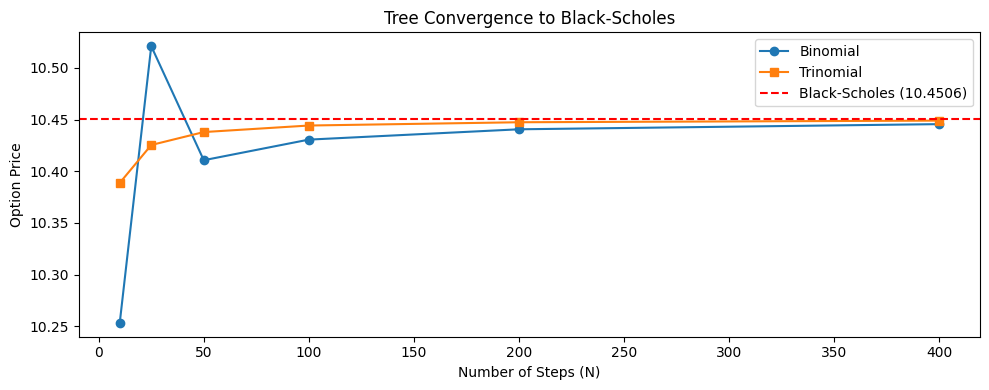

In [23]:
# Tree engines converge to Black-Scholes as N increases
bs_price = Black_Scholes.price(opt)
Ns = [10, 25, 50, 100, 200, 400]

bi_prices  = [Binomial.price(opt, N=n)  for n in Ns]
tri_prices = [Trinomial.price(opt, N=n) for n in Ns]

plt.figure(figsize=(10, 4))
plt.plot(Ns, bi_prices,  marker="o", label="Binomial")
plt.plot(Ns, tri_prices, marker="s", label="Trinomial")
plt.axhline(bs_price, color="red", linestyle="--", label=f"Black-Scholes ({bs_price:.4f})")
plt.title("Tree Convergence to Black-Scholes")
plt.xlabel("Number of Steps (N)")
plt.ylabel("Option Price")
plt.legend()
plt.tight_layout()
plt.show()

### Put-Call Parity
For European options: `C - P = S·e^(-qT) - K·e^(-rT)`. A fundamental no-arbitrage relationship.

In [24]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

call = European(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")
put  = European(S=S, K=K, T=T, r=r, sigma=sigma, option_type="put")

lhs = call.price() - put.price()
rhs = S - K * np.exp(-r * T)

print(f"Call price          : {call.price():.4f}")
print(f"Put price           : {put.price():.4f}")
print(f"C - P               : {lhs:.4f}")
print(f"S - K·e^(-rT)       : {rhs:.4f}")
print(f"Parity holds        : {abs(lhs - rhs) < 1e-6}")

Call price          : 10.4506
Put price           : 5.5735
C - P               : 4.8771
S - K·e^(-rT)       : 4.8771
Parity holds        : True


### Payoff Diagrams
Visualising payoff at expiry for common vanilla strategies.

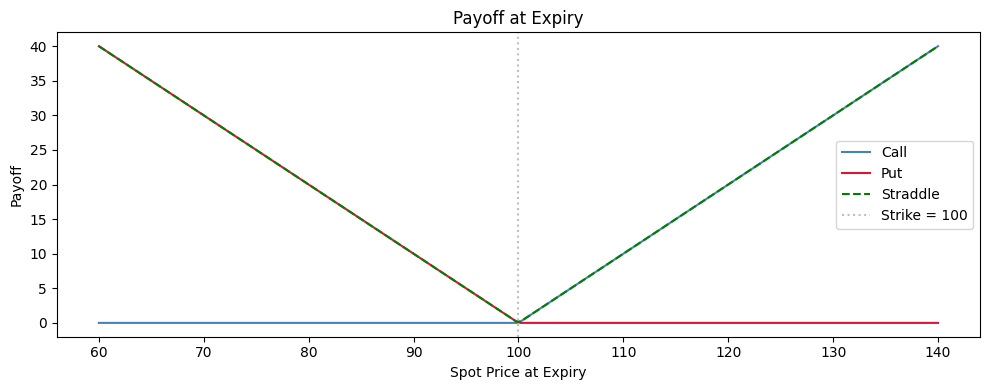

In [25]:
spots = np.linspace(60, 140, 200)
call_payoff    = [max(s - K, 0) for s in spots]
put_payoff     = [max(K - s, 0) for s in spots]
straddle_payoff = [max(s - K, 0) + max(K - s, 0) for s in spots]

plt.figure(figsize=(10, 4))
plt.plot(spots, call_payoff,     label="Call",    color="steelblue")
plt.plot(spots, put_payoff,      label="Put",     color="crimson")
plt.plot(spots, straddle_payoff, label="Straddle",color="green", linestyle="--")
plt.axvline(K, color="gray", linestyle=":", alpha=0.5, label=f"Strike = {K}")
plt.title("Payoff at Expiry")
plt.xlabel("Spot Price at Expiry")
plt.ylabel("Payoff")
plt.legend()
plt.tight_layout()
plt.show()

## 2. American Options
American puts can be exercised early — they are always worth at least as much as European puts.

In [26]:
eu_put = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="put")
am_put = American(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="put")

print(f"European put           : {eu_put.price(engine='binomial', N=200):.4f}")
print(f"American put           : {am_put.price(N=200):.4f}  # defaults to binomial")
print(f"Early exercise premium : {am_put.price(N=200) - eu_put.price(engine='binomial', N=200):.4f}")

European put           : 5.5635
American put           : 6.0864  # defaults to binomial
Early exercise premium : 0.5228


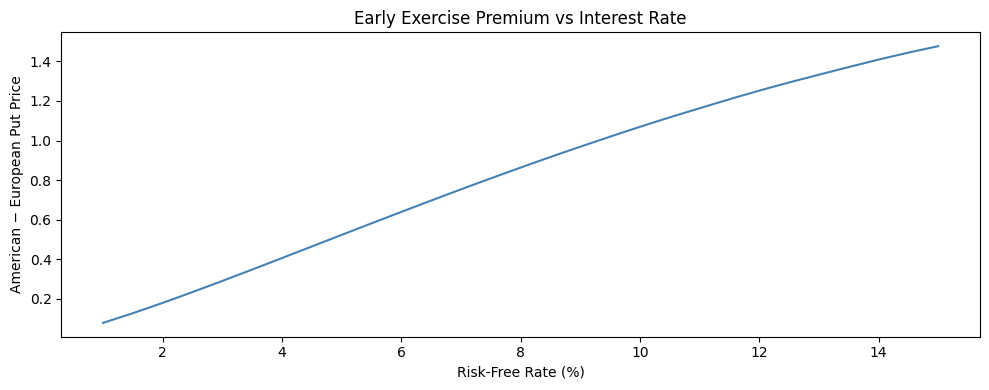

In [27]:
# Early exercise premium grows with interest rate — higher r makes waiting more costly
rates = np.linspace(0.01, 0.15, 30)
eu_prices = [Binomial.price(European(S=100, K=100, T=1, r=r, sigma=0.2, option_type="put"), N=200) for r in rates]
am_prices = [Binomial.price(American(S=100, K=100, T=1, r=r, sigma=0.2, option_type="put"), N=200) for r in rates]
premiums  = [a - e for a, e in zip(am_prices, eu_prices)]

plt.figure(figsize=(10, 4))
plt.plot(rates * 100, premiums, color="steelblue")
plt.title("Early Exercise Premium vs Interest Rate")
plt.xlabel("Risk-Free Rate (%)")
plt.ylabel("American − European Put Price")
plt.tight_layout()
plt.show()

## 3. Greeks
Sensitivities of the option price to market parameters. Analytical for European options, numerical for all others.

In [28]:
opt = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")

# Analytical Greeks via .greeks()
g = opt.greeks()
print("Analytical Greeks (European call):")
for name, val in g.items():
    print(f"  {name.capitalize():<6}: {val:.4f}")

print()

# Numerical Greeks for American put
am_put = American(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="put")
g_num = am_put.greeks(method="numerical")
print("Numerical Greeks (American put):")
for name, val in g_num.items():
    print(f"  {name.capitalize():<6}: {val:.4f}")

Analytical Greeks (European call):
  Delta : 0.6368
  Gamma : 0.0188
  Vega  : 0.3752
  Theta : -0.0176
  Rho   : 0.5323

Numerical Greeks (American put):
  Delta : -0.4225
  Gamma : 2.8498
  Vega  : 37.4409
  Theta : 2.2346
  Rho   : -30.2141


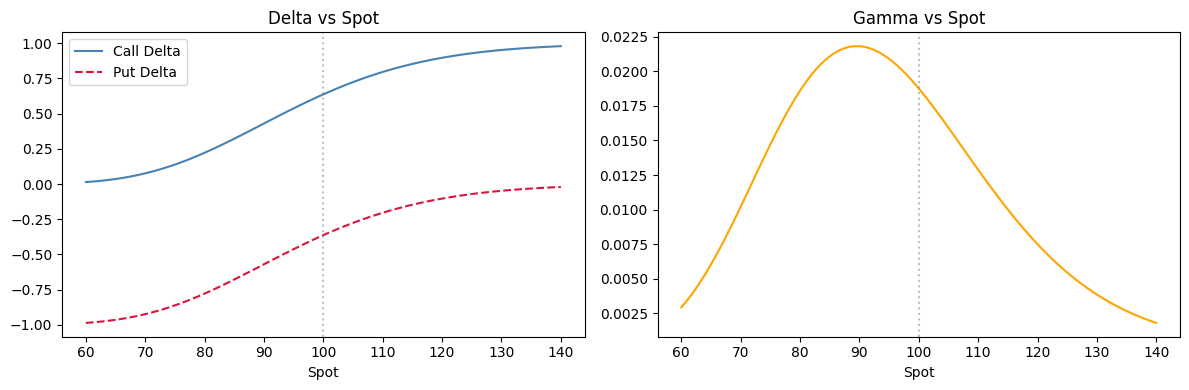

In [29]:
# Delta and Gamma vs Spot
spots = np.linspace(60, 140, 100)
deltas_call = [Greeks.analytical(European(S=s, K=100, T=1, r=0.05, sigma=0.2, option_type="call"), "delta") for s in spots]
deltas_put  = [Greeks.analytical(European(S=s, K=100, T=1, r=0.05, sigma=0.2, option_type="put"),  "delta") for s in spots]
gammas      = [Greeks.analytical(European(S=s, K=100, T=1, r=0.05, sigma=0.2, option_type="call"), "gamma") for s in spots]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(spots, deltas_call, label="Call Delta", color="steelblue")
ax1.plot(spots, deltas_put,  label="Put Delta",  color="crimson", linestyle="--")
ax1.axvline(100, color="gray", linestyle=":", alpha=0.5)
ax1.set_title("Delta vs Spot")
ax1.set_xlabel("Spot")
ax1.legend()
ax2.plot(spots, gammas, color="orange")
ax2.axvline(100, color="gray", linestyle=":", alpha=0.5)
ax2.set_title("Gamma vs Spot")
ax2.set_xlabel("Spot")
plt.tight_layout()
plt.show()

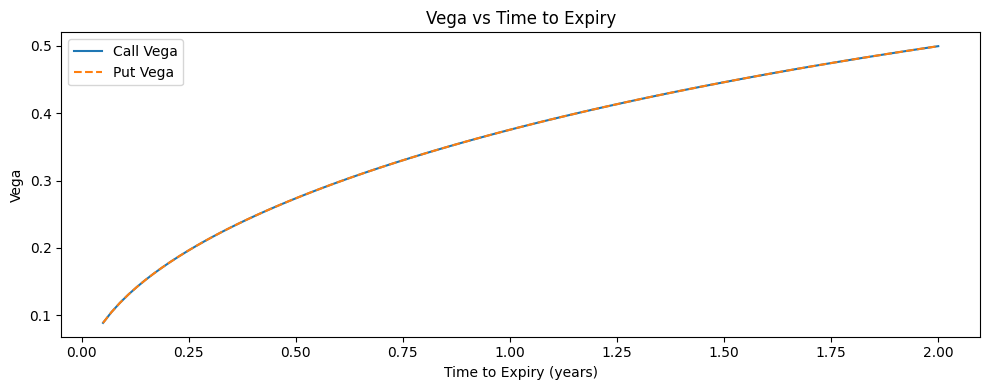

In [30]:
# Vega decays as expiry approaches — time value erodes
tenors = np.linspace(0.05, 2, 100)
vegas_call = [Greeks.analytical(European(S=100, K=100, T=t, r=0.05, sigma=0.2, option_type="call"), "vega") for t in tenors]
vegas_put  = [Greeks.analytical(European(S=100, K=100, T=t, r=0.05, sigma=0.2, option_type="put"),  "vega") for t in tenors]

plt.figure(figsize=(10, 4))
plt.plot(tenors, vegas_call, label="Call Vega")
plt.plot(tenors, vegas_put,  label="Put Vega", linestyle="--")
plt.title("Vega vs Time to Expiry")
plt.xlabel("Time to Expiry (years)")
plt.ylabel("Vega")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Exotic Options
Path-dependent and multi-asset options priced via Monte Carlo. All priced using `.price()` shorthand.

In [31]:
np.random.seed(42)

asian    = Asian(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")
barrier  = Barrier(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call", barrier=120, barrier_type="up-and-out")
lookback = Lookback(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")
spread   = Spread(S1=100, S2=100, K=5, T=1, r=0.05, sigma1=0.2, sigma2=0.2, rho=0.5, option_type="call")
rainbow  = Rainbow(spots=[100, 100], K=100, T=1, r=0.05, sigmas=[0.2, 0.2], rho=0.5, option_type="call")

print(f"Asian    : {asian.price(M=50000):.4f}   (averaging reduces effective vol → cheaper than vanilla)")
print(f"Barrier  : {barrier.price(engine="mc", M=50000):.4f}   (knocked out at 120 → much cheaper)")
print(f"Lookback : {lookback.price(M=50000):.4f}  (hindsight premium → most expensive)")
print(f"Spread   : {spread.price(M=50000):.4f}   (S1 - S2 - K payoff)")
print(f"Rainbow  : {rainbow.price(M=50000):.4f}  (best-of-two → above vanilla)")

Asian    : 5.7360   (averaging reduces effective vol → cheaper than vanilla)
Barrier  : 1.3361   (knocked out at 120 → much cheaper)
Lookback : 18.2457  (hindsight premium → most expensive)
Spread   : 5.8918   (S1 - S2 - K payoff)
Rainbow  : 15.4257  (best-of-two → above vanilla)


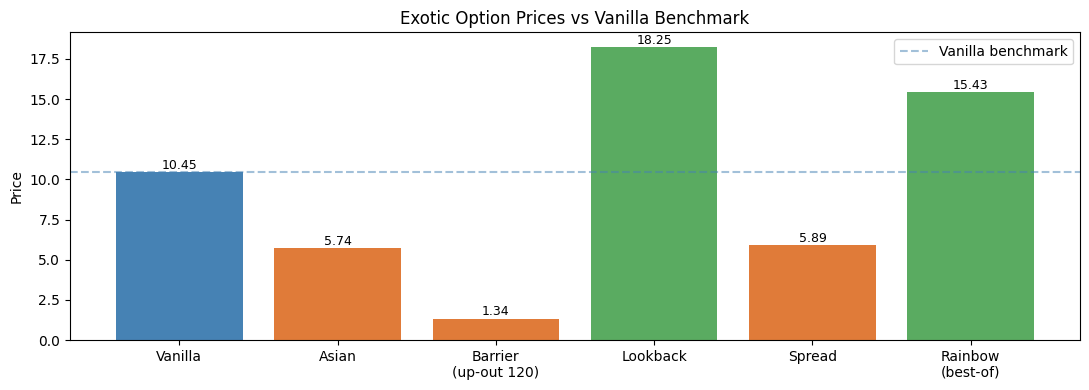

In [32]:
# Visual comparison vs vanilla benchmark
np.random.seed(42)
vanilla_price = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call").price()

labels = ["Vanilla", "Asian", "Barrier\n(up-out 120)", "Lookback", "Spread", "Rainbow\n(best-of)"]
prices = [
    vanilla_price,
    Asian(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call").price(M=50000),
    Barrier(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call", barrier=120, barrier_type="up-and-out").price(engine="mc", M=50000),
    Lookback(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call").price(M=50000),
    Spread(S1=100, S2=100, K=5, T=1, r=0.05, sigma1=0.2, sigma2=0.2, rho=0.5, option_type="call").price(M=50000),
    Rainbow(spots=[100, 100], K=100, T=1, r=0.05, sigmas=[0.2, 0.2], rho=0.5, option_type="call").price(M=50000),
]

colors = ["steelblue"] + ["#e07b39" if p < vanilla_price else "#5aab61" for p in prices[1:]]

plt.figure(figsize=(11, 4))
bars = plt.bar(labels, prices, color=colors)
plt.axhline(vanilla_price, color="steelblue", linestyle="--", alpha=0.5, label="Vanilla benchmark")
plt.title("Exotic Option Prices vs Vanilla Benchmark")
plt.ylabel("Price")
plt.legend()
for bar, price in zip(bars, prices):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{price:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Implied Volatility
Given a market price, back out the volatility the market is implying via Newton-Raphson.

In [33]:
opt = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")
market_price = opt.price()

iv = implied_vol(opt, market_price)
print(f"Market price : {market_price:.4f}")
print(f"Implied vol  : {iv:.4f}")
print(f"Input sigma  : 0.2000")
print(f"Recovered    : {abs(iv - 0.2) < 1e-4}")

Market price : 10.4506
Implied vol  : 0.2000
Input sigma  : 0.2000
Recovered    : True


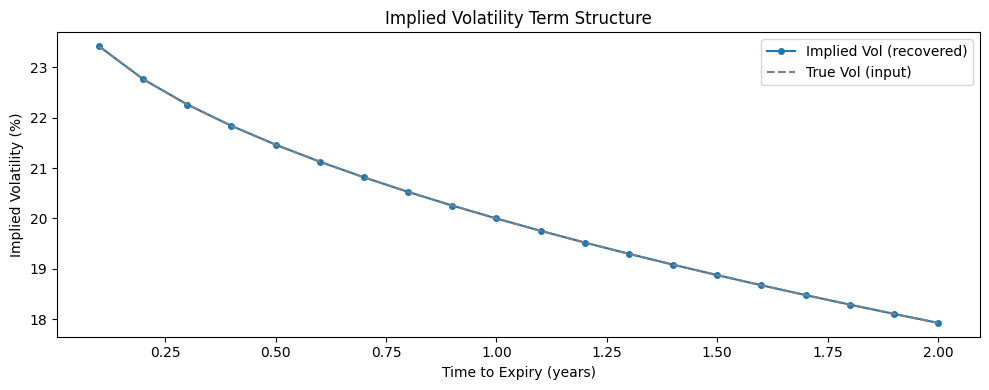

In [34]:
# Vol term structure: short-dated options embed higher uncertainty
tenors = np.linspace(0.1, 2.0, 20)
term_structure_vol = 0.25 - 0.05 * np.sqrt(tenors)

ivs = []
for T, true_vol in zip(tenors, term_structure_vol):
    opt = European(S=100, K=100, T=T, r=0.05, sigma=true_vol, option_type="call")
    market_px = opt.price()
    iv = implied_vol(opt, market_px)
    ivs.append(iv * 100)

plt.figure(figsize=(10, 4))
plt.plot(tenors, ivs, marker="o", markersize=4, label="Implied Vol (recovered)")
plt.plot(tenors, term_structure_vol * 100, linestyle="--", color="gray", label="True Vol (input)")
plt.title("Implied Volatility Term Structure")
plt.xlabel("Time to Expiry (years)")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. GBM Simulation
Asset price paths under Geometric Brownian Motion. Higher volatility means wider dispersion.

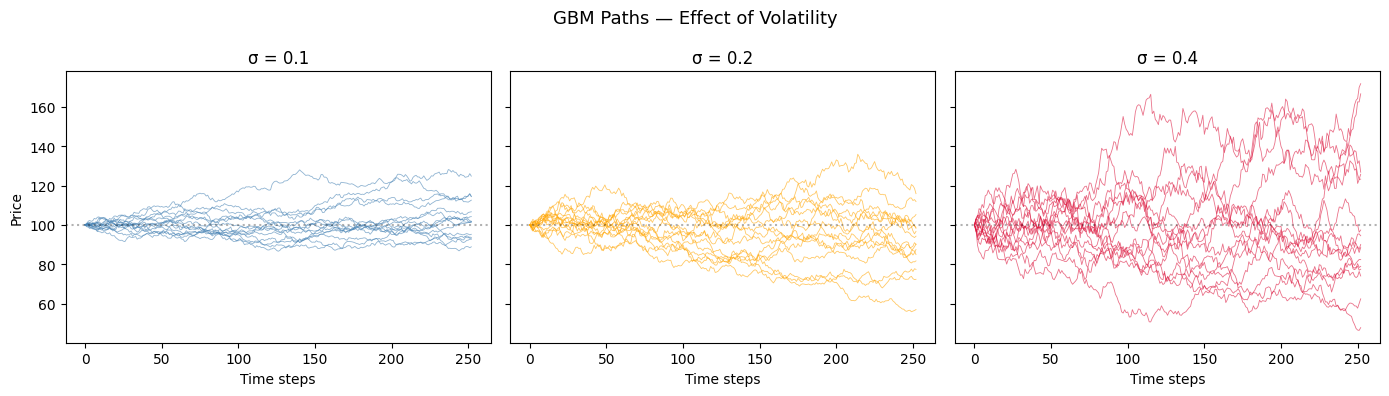

In [35]:
sigmas = [0.1, 0.2, 0.4]
colors = ["steelblue", "orange", "crimson"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, sig, col in zip(axes, sigmas, colors):
    paths = [simulate_gbm(S=100, r=0.05, sigma=sig, T=1, steps=252) for _ in range(15)]
    for path in paths:
        ax.plot(path, lw=0.6, alpha=0.6, color=col)
    ax.axhline(100, color="black", linestyle=":", alpha=0.3)
    ax.set_title(f"σ = {sig}")
    ax.set_xlabel("Time steps")
axes[0].set_ylabel("Price")
fig.suptitle("GBM Paths — Effect of Volatility", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Live Market Pricing
Price a real option using live market data. Spot, risk-free rate, and historical vol are fetched automatically.

In [36]:
# Price an AAPL call expiring in ~6 months
opt = from_market("AAPL", K=200, expiry="2026-12-19", option_type="call")

print(f"Ticker       : AAPL")
print(f"Spot         : {opt.S:.2f}")
print(f"Strike       : {opt.K:.2f}")
print(f"T (years)    : {opt.T:.4f}")
print(f"Risk-free r  : {opt.r:.4f}")
print(f"Hist. sigma  : {opt.sigma:.4f}")
print()
print(f"Price (BS)   : {opt.price():.4f}")
print()
g = opt.greeks()
print("Greeks:")
for name, val in g.items():
    print(f"  {name.capitalize():<6}: {val:.4f}")

Ticker       : AAPL
Spot         : 300.20
Strike       : 200.00
T (years)    : 0.5973
Risk-free r  : 0.0359
Hist. sigma  : 0.2244

Price (BS)   : 104.5394

Greeks:
  Delta : 0.9947
  Gamma : 0.0003
  Vega  : 0.0356
  Theta : -0.0209
  Rho   : 1.1590


## 8. Machine Learning Pricing Engine
Comparing ML predictions against traditional engines on the same option.

Engine             Price     vs BS
----------------------------------
Black-Scholes    10.4506   +0.0000
Binomial         10.4306   -0.0200
Trinomial        10.4442   -0.0064
Monte Carlo      10.3485   -0.1021
ML               10.3832   -0.0674


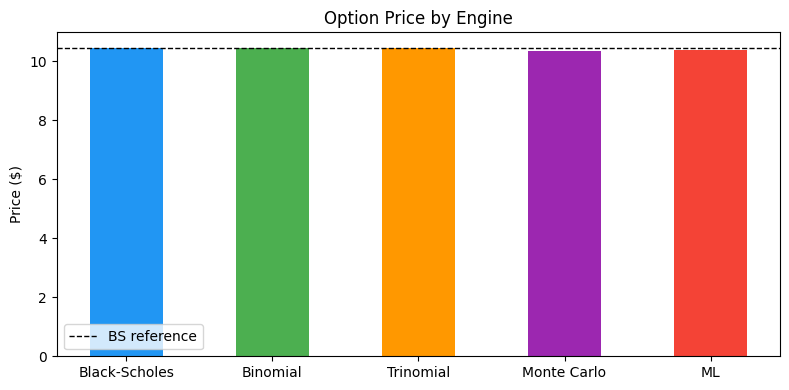

In [37]:
opt = European(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")

np.random.seed(42)
prices = {
    "Black-Scholes" : Black_Scholes.price(opt),
    "Binomial"      : Binomial.price(opt, N=100),
    "Trinomial"     : Trinomial.price(opt, N=100),
    "Monte Carlo"   : MonteCarlo.price(opt, M=50000),
    "ML"            : MLPricer.price(opt),
}

# --- table ---
print(f"{'Engine':<15} {'Price':>8}  {'vs BS':>8}")
print("-" * 34)
bs = prices["Black-Scholes"]
for engine, price in prices.items():
    diff = price - bs
    print(f"{engine:<15} {price:>8.4f}  {diff:>+8.4f}")

# --- bar chart ---
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
ax.bar(prices.keys(), prices.values(), color=colors, width=0.5)
ax.axhline(bs, color="black", linestyle="--", linewidth=1, label="BS reference")
ax.set_title("Option Price by Engine")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

### ML Sensitivity Analysis
Comparing ML vs Black-Scholes across moneyness, volatility, and time to expiry.

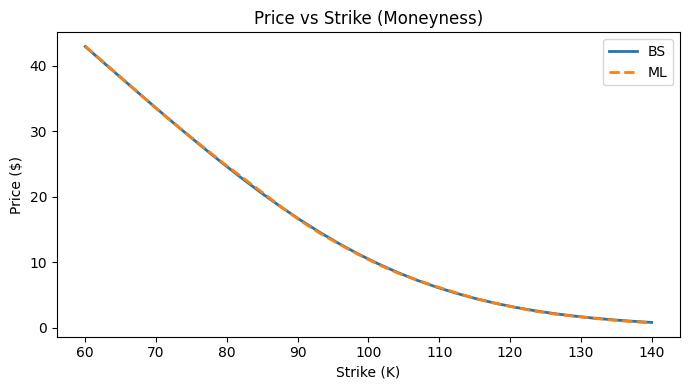

In [38]:
strikes = np.linspace(60, 140, 30)
bs_prices = [Black_Scholes.price(European(S=100, K=k, T=1, r=0.05, sigma=0.2, option_type="call")) for k in strikes]
ml_prices = [MLPricer.price(European(S=100, K=k, T=1, r=0.05, sigma=0.2, option_type="call")) for k in strikes]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strikes, bs_prices, label="BS", linewidth=2)
ax.plot(strikes, ml_prices, label="ML", linewidth=2, linestyle="--")
ax.set_title("Price vs Strike (Moneyness)")
ax.set_xlabel("Strike (K)")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

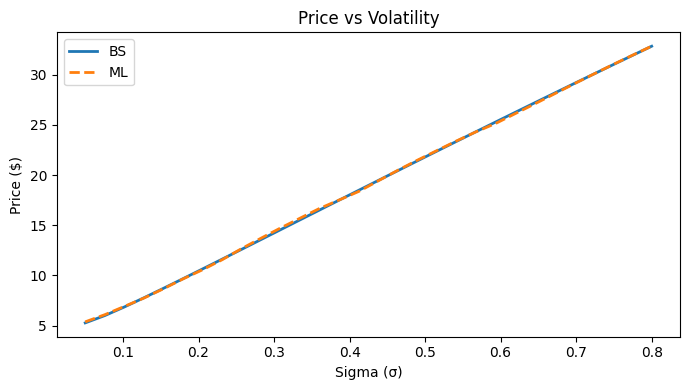

In [39]:
sigmas = np.linspace(0.05, 0.8, 30)
bs_prices = [Black_Scholes.price(European(S=100, K=100, T=1, r=0.05, sigma=s, option_type="call")) for s in sigmas]
ml_prices = [MLPricer.price(European(S=100, K=100, T=1, r=0.05, sigma=s, option_type="call")) for s in sigmas]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigmas, bs_prices, label="BS", linewidth=2)
ax.plot(sigmas, ml_prices, label="ML", linewidth=2, linestyle="--")
ax.set_title("Price vs Volatility")
ax.set_xlabel("Sigma (σ)")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

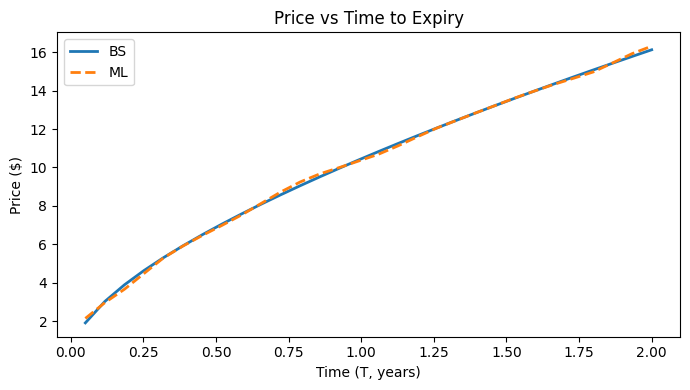

In [40]:
tenors = np.linspace(0.05, 2.0, 30)
bs_prices = [Black_Scholes.price(European(S=100, K=100, T=t, r=0.05, sigma=0.2, option_type="call")) for t in tenors]
ml_prices = [MLPricer.price(European(S=100, K=100, T=t, r=0.05, sigma=0.2, option_type="call")) for t in tenors]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tenors, bs_prices, label="BS", linewidth=2)
ax.plot(tenors, ml_prices, label="ML", linewidth=2, linestyle="--")
ax.set_title("Price vs Time to Expiry")
ax.set_xlabel("Time (T, years)")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()